# Working Experience Impact on Salary

In [17]:
# Importing required libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [50]:
# Loading dataset
try:
    file_path = r"C:\projects\dataset\Salary_Data.csv"
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("File not found!")

In [6]:
# Explore first few records
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
# Checking dataset basics information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [48]:
# Checking Missing values
print(df.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


In [47]:
# Checking duplicated records
print(f"The number of duplicated records: {df.duplicated().sum():,}")

The number of duplicated records: 0


In [9]:
# Summary statistics for Numerical variables
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## Simple Linear Regression Model

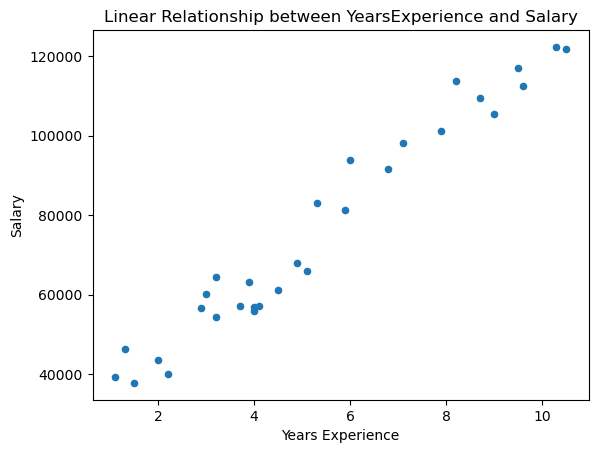

In [40]:
#  Checking linearity
df.plot(kind="scatter", x="YearsExperience", y="Salary")
plt.title("Linear Relationship between YearsExperience and Salary")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

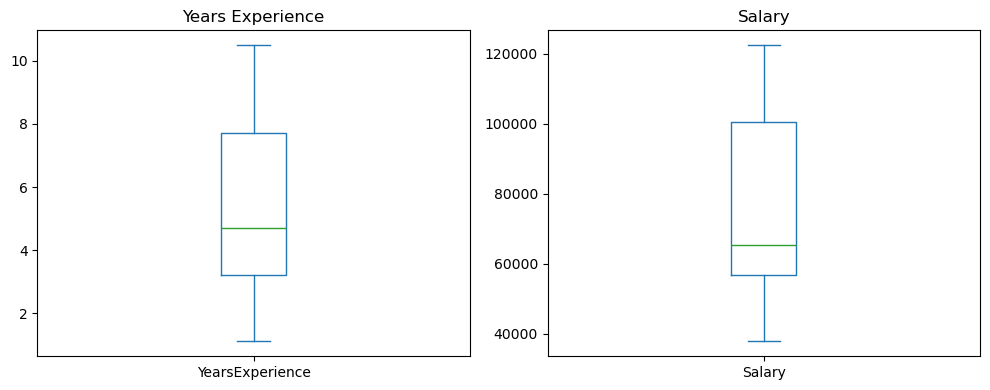

In [36]:
# Checking outliers
fig, axs=plt.subplots(1,2, figsize=(10,4))
df["YearsExperience"].plot(kind="box", ax=axs[0], title="Years Experience")
df["Salary"].plot(kind="box", ax=axs[1], title="Salary")
plt.tight_layout()
plt.show()

In [41]:
# Computing the Pearson's Correlation Coefficient
import scipy.stats as sc
r = sc.pearsonr(df["YearsExperience"], df["Salary"])
print("Pearson r = ", round(r[0], 4), "with p-value = ", round(r[1], 4))

Pearson r =  0.9782 with p-value =  0.0


In [42]:
# Fitting the Regression Model
import statsmodels.formula.api as smf
model = smf.ols("Salary~YearsExperience", data=df, missing="drop")
result = model.fit()

In [43]:
print(result.params)

Intercept          25792.200199
YearsExperience     9449.962321
dtype: float64


In [44]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           1.14e-20
Time:                        19:38:19   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        2.579e+04   2273.053     

### 1. Model Assumptions Verification

* **Normality of Residuals (ကြွင်းကျန်ကိန်းများ၏ ပုံမှန်ဖြန့်ဝေမှု):**
    * *သုံးသပ်ချက်:* "OLS Regression ၏ အရေးကြီးသည့် ယူဆချက်တစ်ခုမှာ Error Term(Residuals) များသည် Normal Distribution ဖြစ်ရပါမည်။ ဒီမော်ဒယ်တွင် **Prob(Omnibus)** တန်ဖိုးသည် **0.343** နှင့် **Prob(JB)** တန်ဖိုးသည် **0.456** (both > 0.05) ဖြစ်သောကြောင့် Residuals များသည် Normal Distribution ဖြစ်သည်ဟု ယုံကြည်စိတ်ချစွာ လက်ခံနိုင်ပါသည်။"
* **Independence of Errors (အမှားများ၏ လွတ်လပ်မှု):**
    * *သုံးသပ်ချက်:* "**Durbin-Watson** တန်ဖိုးသည် **1.648** ဖြစ်ပါသည်။ ဤတန်ဖိုးသည် 2 နှင့် နီးစပ်သောကြောင့် Autocorrelation ပြဿနာ (Data တစ်ခုနှင့်တစ်ခု မှီခိုနေမှု) မရှိကြောင်း တွေ့ရှိရသည်။"

### 2. Limitations

* "ဤမော်ဒယ်သည် **Sample Size (30)** ပေါ်တွင်သာ အခြေခံထားသောကြောင့် အချက်အလက်အသစ်များ (Unseen Data) ဝင်လာပါက တိကျမှု အနည်းငယ်ပြောင်းလဲနိုင်ပါသည်။"
* "Linear Regression ဖြစ်သည့်အတွက် လစာတိုးနှုန်းသည် အမြဲတမ်း Linear (မျဉ်းဖြောင့်) အတိုင်းသွားမည်ဟု ယူဆထားသော်လည်း၊ လက်တွေ့တွင် Senior Management Level ၌ လစာတိုးနှုန်းပုံစံ ပြောင်းလဲနိုင်ပါသည်။"

---

### 3. Conclusion

**Conclusion and Model Validity**

ဤလေ့လာမှုအရ **Simple Linear Regression Model** သည် လုပ်သက်နှင့် လစာအကြား ဆက်နွယ်မှုကို ရှင်းပြရာတွင် အလွန်ထိရောက်မှုရှိကြောင်း တွေ့ရှိရပါသည်။
1.  **Predictive Power:** $R^2$ တန်ဖိုး **0.957** ရှိခြင်းက မော်ဒယ်၏ ခန့်မှန်းနိုင်စွမ်း အလွန်မြင့်မားကြောင်း ပြသနေပါသည်။
2.  **Statistical Reliability:** **Prob(F-statistic)** တန်ဖိုးသည် $1.14 \times 10^{-20}$ (near zero) ဖြစ်သောကြောင့် မော်ဒယ်တစ်ခုလုံး၏ ရလဒ်သည် စာရင်းအင်းပညာအရ အလွန်ခိုင်မာမှု (Highly Significant) ရှိပါသည်။
3.  **Validity Checks:** မော်ဒယ်၏ **Omnibus** နှင့် **Jarque-Bera** probability တန်ဖိုးများသည် $0.05$ ထက် ကြီးမားနေသဖြင့် OLS ၏ အခြေခံစည်းမျဉ်း (Normality Assumption) ကို ချိုးဖောက်ခြင်း မရှိကြောင်း အတည်ပြုနိုင်ပါသည်။

**Regression Equation:**

$$\text{Salary} = 25,792.2 + 9,449.96(\text{YearsExperience}) + \epsilon$$

**အနှစ်ချုပ်အားဖြင့်:** ဤမော်ဒယ်သည် လုပ်သက် (YearsExperience) ကို အသုံးပြု၍ ဝန်ထမ်းတစ်ဦး၏ လစာကို ခန့်မှန်းရာတွင် ယုံကြည်စိတ်ချစွာ (Robust & Reliable) အသုံးပြုနိုင်သော မော်ဒယ်တစ်ခု ဖြစ်ပါသည်။

---